In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Exploração inicial do df

In [3]:
df = pd.read_csv("../data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


"Cabin" aparenta ser a única coluna com uma quantia significativa de dados faltantes. Outras colunas como "Sex" e "Age" também possuem valores nulos (NaN), mas nada que comprometa a análise.

Os tipos de dados também aparentam estar coerentes com o esperado.

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Aqui, nota-se que não há valores absurdos (como valores negativos ou muito grandes) em colunas como idade e valor do ticket.

In [25]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Family size
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658,-0.040143
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.065997
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,-0.301914
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,0.890712
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,0.783111
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,0.217138
Family size,-0.040143,0.016639,0.065997,-0.301914,0.890712,0.783111,0.217138,1.000000


Essa tabela de correlações traz uma primeira análise geral da correlação entre as variáveis, por exemplo:
- Survived x Pclass tem uma correlação negativa (~ -0.34), indicando que: maior classe -> menor sobrevivência
- Survived x Fare tem uma correlação positiva (~ +0.26), indicando que: maior valor da passagem -> maior sobrevivência
- etc

In [6]:
df["Parch"].unique()

array([0, 1, 2, 5, 3, 4, 6])

In [7]:
df["SibSp"].unique()

array([1, 0, 3, 4, 2, 5, 8])

In [8]:
df["Embarked"].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [9]:
df["Pclass"].unique()

array([3, 1, 2])

Pela breve análise inicial, foi possível observar a forma geral desse dataset do Titanic.
Existem dados de 891 passageiros, divididos em 12 categorias (colunas): 

- ID do passageiro (int);
- Se o passageiro sobreviveu ou não ao desastre (bin);
- Classe à qual o passageiro embarcou. Sendo elas: 1ª,2ª ou 3ª classe (int));
- Nome (str);
- Sexo (str);
- Idade (float);
- Quantia de irmãos(ãs) e/ou conjuges do passageiro à bordo (int);
- Quantia de filhos e/ou parentes do passageiro à bordo (int);
- Identificador do bilhete do passageiro (str);
- Valor do ingresso de entrada, associado à classe do passageiro (float);
- Cabine em que o passageiro se hospedou (str);
- Onde o passageiro embarcou. À saber: Southampton (Inglaterra), Cherbourg (França) ou Queenstown (Irlanda) (str).

A análise inicial mostrou que o dataset parece já estar bem tratado e com valores coerentes, prontos para uma investigação.

## Investigação dos dados

Como não há necessidade crítica de fazer tratamento de dados, essa seção já irá se voltar para uma investigação dos dados, analisando alguns aspectos como taxa de sobrevivência, etc.

In [10]:
(df["Embarked"].value_counts(normalize=True) * 100).round(0)

Embarked
S    72.0
C    19.0
Q     9.0
Name: proportion, dtype: float64

In [11]:
(df["Pclass"].value_counts(normalize=True) * 100).round(0)

Pclass
3    55.0
1    24.0
2    21.0
Name: proportion, dtype: float64

Aqui, nota-se que a maior parte dos passageiros (~55%) está na 3ª classe e o restante dividido entre a 1ª e a 2ª. Além disso, nota-se que a grande maioria dos passageiros (~72%) embarcou na Inglaterra (o ponto de partida original do Titanic), cerca de 20% na França e o restante na Irlanda.

In [12]:
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

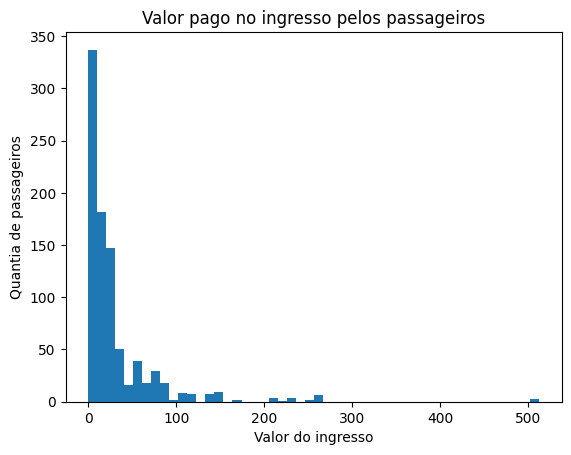

In [13]:
df["Fare"].hist(bins=50)
plt.grid(False)
plt.title("Valor pago no ingresso pelos passageiros")
plt.xlabel("Valor do ingresso")
plt.ylabel("Quantia de passageiros")
plt.show()

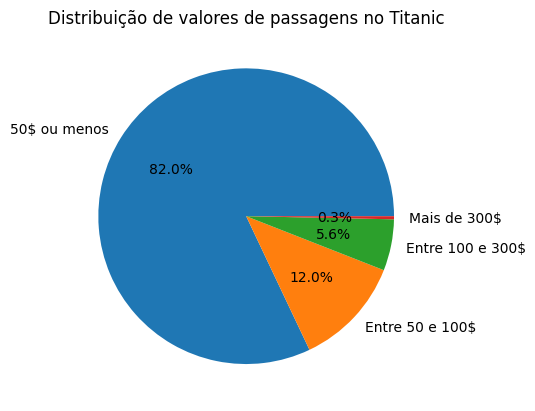

In [14]:
bilhetes = pd.Series({
    "50$ ou menos"     : (df["Fare"] <= 50).sum(),
    "Entre 50 e 100$"  : ((df["Fare"] > 50) & (df["Fare"] <= 100.0)).sum(), 
    "Entre 100 e 300$" : ((df["Fare"] > 100.0) & (df["Fare"] <= 300.0)).sum(), 
    "Mais de 300$"     : (df["Fare"] > 300.0).sum()
})

bilhetes.plot.pie(autopct="%.1f%%")
plt.title("Distribuição de valores de passagens no Titanic")
plt.show()

Com base nesses últimos dois gráficos, é possível analisar a distruição do valor das passagens no Titanic. Como é de se esperar, há uma quantia muito maior (acima de 80%) de passagens de baixo-valor (provavelmente associadas à 3ª classe), poucas com valores intermediários, e pouquíssimas (menos de 1%) com valores exorbitantes (possivelmente VIPs).

Isso demonstra que havia uma clara dissociação de renda entre os passageiros à bordo do Titanic.

In [15]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Observamos que 549 dos 891 passageiros do Titanic (cerca de 60%) não sobreviveram ao desastre. 342 sobreviveram e há 28 passageiros com status desconhecido.

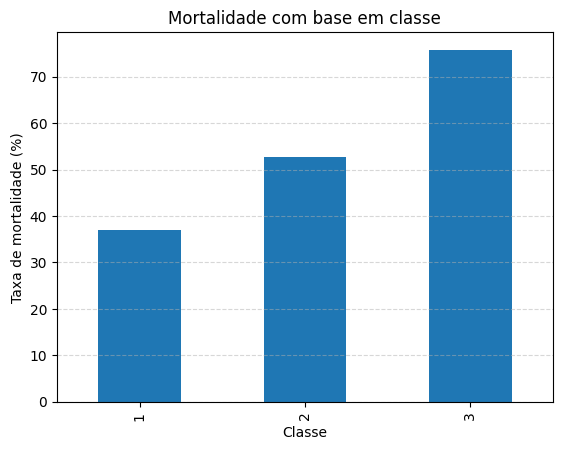

In [16]:
taxa_sobrevivencia_por_classe = df.groupby("Pclass")["Survived"].mean()
taxa_mortalidade_por_classe = 1 - taxa_sobrevivencia_por_classe
taxa_mortalidade_por_classe = taxa_mortalidade_por_classe * 100
taxa_mortalidade_por_classe.plot(kind="bar")
plt.xlabel("Classe")
plt.ylabel("Taxa de mortalidade (%)")
plt.title("Mortalidade com base em classe")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

A taxa de mortalidade da 1ª classe (~35%) foi menor que para a 2ª classe (~50%), que por sua vez foi menor que a taxa de mortalidade da 3ª classe. Isso é um indício de uma priorização em salvar os passageiros mais ricos primeiro.

In [17]:
df["Family size"] = df["SibSp"] + df["Parch"] + 1
familias = df["Family size"].value_counts().sort_index()
familias

Family size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

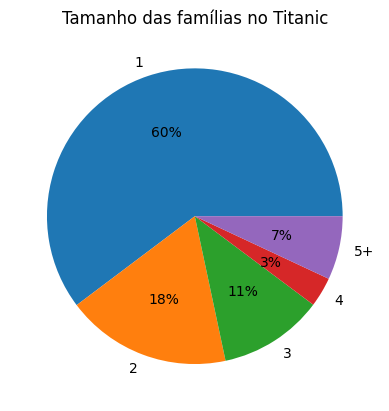

In [18]:
grafico_familias = familias[familias.index < 5]
grafico_familias["5+"] = familias[familias.index >= 5].sum()

grafico_familias.plot.pie(autopct="%.0f%%")
plt.title("Tamanho das famílias no Titanic")
plt.show()

Com o gráfico fica fácil notar que a maioria dos passageiros à bordo do Titanic estavam sozinhos(as). Famílias de 4 ou mais indivíduos representam apenas cerca de 10% do total.

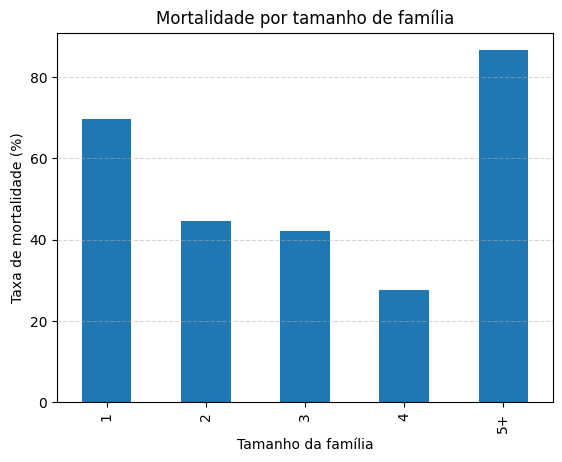

In [19]:
taxa_sobrevivencia_familias = df.groupby("Family size")["Survived"].mean()
taxa_mortalidade_familias = 1 - taxa_sobrevivencia_familias

grafico_mortalidade_familias = taxa_mortalidade_familias[
    taxa_mortalidade_familias.index < 5
].copy()

grafico_mortalidade_familias.loc[5] = taxa_mortalidade_familias[
    taxa_mortalidade_familias.index >= 5
].mean()

grafico_mortalidade_familias = grafico_mortalidade_familias * 100 # Para ficar em %
grafico_mortalidade_familias.index = ["1","2","3","4","5+"]
grafico_mortalidade_familias.plot(kind="bar")
plt.xlabel("Tamanho da família")
plt.ylabel("Taxa de mortalidade (%)")
plt.title("Mortalidade por tamanho de família")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


Quando avalia-se a taxa de mortalidade das famílias, nota-se que famílias muito grandes (mais de 5 indivíduos) tiveram uma taxa de mortalidade muito elevada (acima de 80%), o que é plausível: com muitos indivíduos, há uma chance de que pelo menos 1 (ou mais) não sobrevivam.
Curiosamente, famílias de 4 membros tiveram a menor mortalidade no quadro (abaixo de 40%).

Ademais, passageiros sozinhos(as) tiveram uma taxa de mortalidade relativamente alta também (acima de 60%).

In [20]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

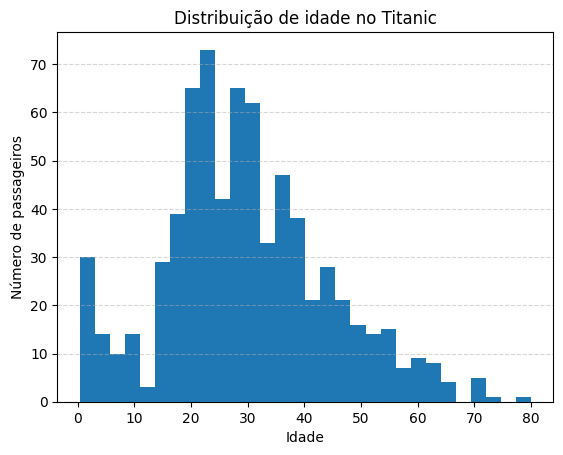

In [21]:

df["Age"].hist(bins=30)
plt.xlabel("Idade")
plt.ylabel("Número de passageiros")
plt.title("Distribuição de idade no Titanic")
plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Os dados mostram que há uma maior concentração de pessoas numa faixa etária de ~20 a ~40 anos de idade, sendo a maioria composta pelo sexo masculino. Há também uma quantia relativamente significativa de bebês à bordo.

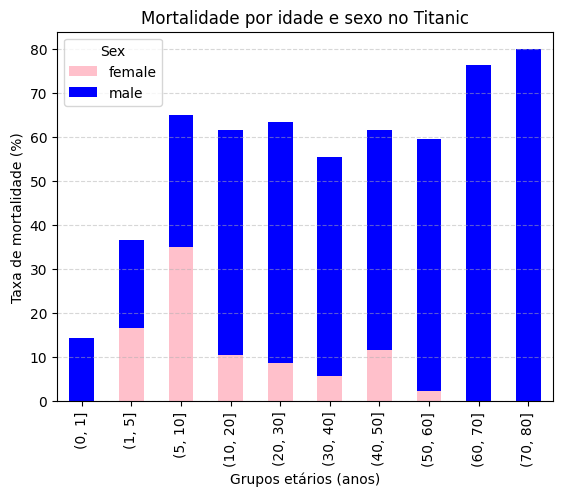

In [22]:
grupos_idade = [0,1,5,10,20,30,40,50,60,70,80]
df["Age group"] = pd.cut(
    df["Age"], 
    bins = grupos_idade
)

mortos = df[df["Survived"] == 0]
mortos_categorizados = mortos.groupby(
    ["Age group", "Sex"]
).size()
mortalidade_por_idadesexo = mortos_categorizados.unstack()

total_por_grupo_de_idade = df.groupby("Age group").size()

taxa_mortalidade_por_idadesexo = mortalidade_por_idadesexo.div(
    total_por_grupo_de_idade, 
    axis=0
)
taxa_mortalidade_por_idadesexo = taxa_mortalidade_por_idadesexo * 100
taxa_mortalidade_por_idadesexo.plot(
    kind="bar", 
    stacked=True, 
    color=["pink", "blue"]
)

plt.xlabel("Grupos etários (anos)")
plt.ylabel("Taxa de mortalidade (%)")
plt.title("Mortalidade por idade e sexo no Titanic")
plt.grid(axis="y", linestyle="--", alpha=0.5)

Com base neste último gráfico, é possível notar um padrão: a taxa de mortalidade masculina foi muito maior do que a feminina, para todas as idades. Isso indica que, provavelmente, houve um protocolo durante o desastre de priorizar em salvar as mulheres.

Além disso, também é possível observar que a taxa de mortalidade dos bebês foi proporcionalmente a mais baixa em relação à outros grupos etários - sinalizando para uma priorização em salvá-los, também.

## Conclusão

A partir da análise feita, foi possível observar que:
- A maior parte dos passageiros à bordo não estavam acompanhados e faziam parte da 3ª classe
- A maioria dos passageiros embarcou na Inglaterra, em Southampton
- Em termos demográficos, a maior parte dos passageiros era do sexo masculino, na faixa etária de 20-40 anos. Também haviam haviam
- As taxas de mortalidade foram muito mais altas dentre homens e pessoas mais velhas. Mulheres e bebês tiveram menor taxa de mortalidade
- A mortalidade foi menor para a 1ª classe em relação à 3ª classe

## Salvar dados

In [24]:
df.to_csv("../data/titanic_modificado.csv", index=False)